In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
sys.path.append("../")
from diabnet.apply import Predictor
from diabnet.data import get_feature_names

In [11]:
c = get_feature_names("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv", BMI=False, sex=True, parents_diagnostics=True)

In [12]:
c[990:]

['snp_9_68692515',
 'snp_12_53198338',
 'snp_6_37571581',
 'snp_20_52032232',
 'snp_20_52032233',
 'snp_20_26104019',
 'snp_20_50189624',
 'snp_1_143276644',
 'snp_16_9536673',
 'snp_20_25734788',
 'AGE',
 'sex',
 'mo_t2d',
 'fa_t2d']

In [57]:
pred = Predictor('../diabnet/models/teste-sp-soft-label_tmp.pth', c, "../datasets/visits_sp_unique_test_positivo_1000_random_0_negatives_older60.csv")

NEGATIVE FILE ../datasets/visits_sp_unique_test_positivo_1000_random_0_negatives_older60.csv


In [87]:
df = pd.read_csv("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv")
id = 549
features = df[c].iloc[id].values
label = df["T2D"].iloc[id]

In [88]:
info = ["AGE", "T2D"]
df[info].iloc[id]

AGE    30
T2D     1
Name: 549, dtype: int64

In [89]:
probs = pred.patient(features, age=60)
neg = pred.negatives(age=60)
np.random.shuffle(neg)

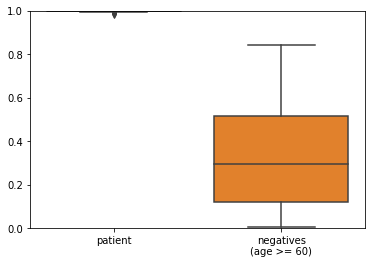

In [90]:
sns.boxplot(x=['patient', 'negatives\n(age >= 60)'], y= [probs[:100], neg[:100]])
plt.ylim(0,1);

In [78]:
neg_life = pred.negatives_life(samples=100)

In [91]:
probs_life = pred.patient_life(features, samples=100)

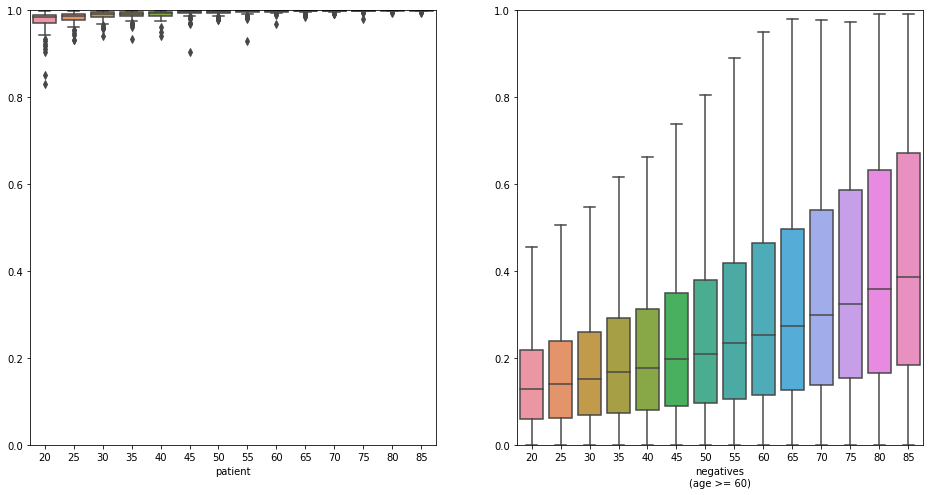

In [92]:
plt.figure(figsize=(16,8))
plt.subplot(121)
sns.boxplot(x=[i for i in probs_life[1]], y=probs_life[0]);
plt.xlabel("patient")
plt.ylim(0,1);
plt.subplot(122)
sns.boxplot(x=[i for i in neg_life[1]], y=neg_life[0], showfliers=False);
plt.xlabel("negatives\n(age >= 60)")
plt.ylim(0,1);
plt.savefig("negative-lifetime-boxplots.png")

In [97]:
df[["id","AGE", "mo_t2d","fa_t2d", "T2D", "mo", "fa"]]

,id,AGE,mo_t2d,fa_t2d,T2D,mo,fa
0,A11123,51,2.0,2.0,1,0,0
1,A00551,40,0.0,1.0,0,A00548,A00547
2,A02267,52,0.0,2.0,1,A02254,A20031
3,A00586,34,0.0,1.0,0,A00300,A00585
4,A16039,37,1.0,1.0,0,A02064,A02063
...,...,...,...,...,...,...,...
545,A02889,36,1.0,0.0,0,A02156,A02149
546,A26102,41,0.0,2.0,0,A01009,A26053
547,A03220,67,2.0,2.0,0,A23019,A23015
548,A39026,41,0.0,2.0,0,A39014,A39020
